# 子图持久化策略
- Per-Invocation: 子图每次调用。支持检查点保存、中断恢复，但不支持记忆对话
    - 声明方式：`subgraph.compile()`
    - 底层逻辑：子图命名空间格式为{所在父图节点名称}:{任务ID},每次调用任务ID都不一致，实现调用隔离,
- Per-thread: 每个会话。支持检查点保存、中断恢复和记忆对话
    - 声明方式: `subgraph.compile(checkpointer=True)`
    - 底层逻辑：子图命名空间格式就是{所在父图节点名称},所以可以跨调用共i昂
- Stateless: 无状态，检查点保存、中断恢复、记忆对话全不支持， 且渲染图无法展开子图的拓扑
    - 声明方式: `subgraph.compile(checkpointer=False)`

## 三种持久化策略中断对比

2026-08-14 19:02:17.793 | INFO     | __main__:subgraph_strip_node:15 - 子图 subgraph_strip_node 节点执行了
2026-08-14 19:02:17.795 | INFO     | __main__:subgraph_punctuate_node:24 - 子图 subgraph_punctuate_node 节点执行了


============================== ->   中断信息   <- ==============================
{'raw_text': '   LangGraph 真有意思        ', '__interrupt__': [Interrupt(value='您希望在句尾添加的标点符号是？[。/，/！/？/；]', id='06be3646271b3145f0814391b46a7718')]}


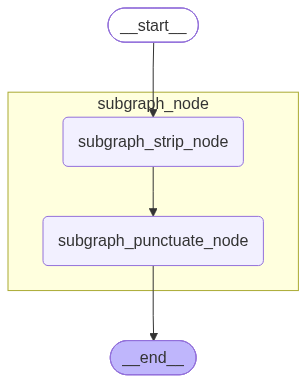

2026-08-14 19:02:18.665 | INFO     | __main__:subgraph_punctuate_node:24 - 子图 subgraph_punctuate_node 节点执行了
2026-08-14 19:02:18.669 | INFO     | __main__:subgraph_punctuate_node:24 - 子图 subgraph_punctuate_node 节点执行了


============================== ->   原始文本   <- ==============================
   LangGraph 真有意思        
============================== -> 清洗后的文本 <- ==============================
LangGraph 真有意思！！


In [11]:
from typing import TypedDict

from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger
from torch.utils.data.datapipes.utils import snapshot


# 定义全局共享状态
class OverAllState(TypedDict):
    raw_text: str # 未清洗文本
    cleaned_text: str # 清洗后的文本

# 构建子图
def subgraph_strip_node(state: OverAllState) -> OverAllState:
    logger.info("子图 subgraph_strip_node 节点执行了")
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "cleaned_text": stripped_text
    }

def subgraph_punctuate_node(state: OverAllState) -> OverAllState:
    logger.info("子图 subgraph_punctuate_node 节点执行了")
    cleaned_text = state["cleaned_text"]
    punctuation = interrupt("您希望在句尾添加的标点符号是？[。/，/！/？/；]")
    punctuation1 = interrupt("您希望在句尾添加的标点符号是？[。/，/！/？/；]")
    punctuated_text = cleaned_text + punctuation + punctuation1

    return {
        "cleaned_text": punctuated_text
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile()  # Per-invocation（默认）
subgraph = builder.compile(checkpointer=True)   # Per-thread
# subgraph = builder.compile(checkpointer=False)  # Stateless（中断不可用）
# ==================================================

# 构建父图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_node", subgraph)

builder.add_edge(START, "subgraph_node")
builder.add_edge("subgraph_node", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

raw_text = "   LangGraph 真有意思        "
config = {"configurable": {"thread_id": "123"}}
# 首次调用
interrupted_res = parent_graph.invoke(
    {"raw_text": raw_text},
    config=config
)
print("=" * 30, "->   中断信息   <-", "=" * 30)
print(interrupted_res)


from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

# 恢复调用
parent_graph.invoke(
    Command(resume="！"),
    config=config
)
res = parent_graph.invoke(
    Command(resume="！"),
    config=config
)

cleaned_text = res["cleaned_text"]
print("=" * 30, "->   原始文本   <-", "=" * 30)
print(raw_text)
print("=" * 30, "-> 清洗后的文本 <-", "=" * 30)
print(cleaned_text)

## 三种持久化策略多轮对话

2026-08-15 09:07:13.309 | INFO     | __main__:llm_node:26 - ==============================
2026-08-15 09:07:13.310 | INFO     | __main__:llm_node:27 - 调用子图的 llm_node 节点，当前的 messages: 
2026-08-15 09:07:13.311 | INFO     | __main__:llm_node:29 - 
[消息 1]
类型：system
内容：尽可能用简短的语言回答
2026-08-15 09:07:13.312 | INFO     | __main__:llm_node:29 - 
[消息 2]
类型：human
内容：我是老王，从现在开始，你是小王
2026-08-15 09:07:13.313 | INFO     | __main__:llm_node:37 - ==============================
============================== -> 第一次调用 <- ==============================
{'user_input': '我是老王，从现在开始，你是小王', 'assistant_response': '好的，老王。'}
2026-08-15 09:07:14.585 | INFO     | __main__:llm_node:26 - ==============================
2026-08-15 09:07:14.586 | INFO     | __main__:llm_node:27 - 调用子图的 llm_node 节点，当前的 messages: 
2026-08-15 09:07:14.586 | INFO     | __main__:llm_node:29 - 
[消息 1]
类型：system
内容：尽可能用简短的语言回答
2026-08-15 09:07:14.587 | INFO     | __main__:llm_node:29 - 
[消息 2]
类型：human
内容：我是老王，从现在开始，你是小王
2026-08-15 09:07:14.588

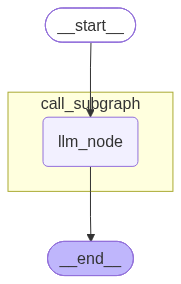

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
# 删除 Loguru 默认的 stderr sink
logger.remove()
# 重新添加支持颜色的 sink
logger.add(sys.stdout, colorize=True)

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 构建子图
def llm_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用子图的 llm_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)

    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile()  # Per-invocation（默认）：无记忆
subgraph = builder.compile(checkpointer=True)   # Per-thread：有记忆
# ==================================================

# 构建父图
class OverAllState(TypedDict):
    user_input: str # 用户提问
    assistant_response: str # 助手回答

def call_subgraph(state: OverAllState) -> OverAllState:
    user_input = state["user_input"]

    messages = [
        SystemMessage("尽可能用简短的语言回答"),
        HumanMessage(user_input)
    ]
    subgraph_response = subgraph.invoke(
        {"messages": messages}
    )

    assistant_response = subgraph_response["messages"][-1].content

    return {
        "assistant_response": assistant_response
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "multi-turn-demo"}}

first_invoke = parent_graph.invoke(
    {"user_input": "我是老王，从现在开始，你是小王"},
    config = config
)
print("=" * 30, "-> 第一次调用 <-", "=" * 30)
print(first_invoke)

second_invoke = parent_graph.invoke(
    {"user_input": "我是谁？你是谁？"},
    config = config
)
print("=" * 30, "-> 第二次调用 <-", "=" * 30)
print(second_invoke)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

### 比较Per-Invocation和Per-thread的检查点快照

In [9]:
from rich import print as rprint
subgraph_config = list(parent_graph.get_state_history(config=config))[-2].tasks[0].state
rprint(subgraph_config)
rprint(list(parent_graph.get_state_history(config=subgraph_config)))

{
    'configurable': {
        'thread_id': 'multi-turn-demo',
        'checkpoint_ns': 'call_subgraph:aaaa1078-2005-38d2-3dfc-1baaed802d53'
    }
}

[]

In [8]:
from rich import print as rprint
rprint(list(parent_graph.get_state_history(config=config)))

[
    StateSnapshot(
        values={'user_input': '我是谁？你是谁？', 'assistant_response': '你老王，我小王。'},
        next=(),
        config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-7b0e-6240-8004-adebd157ff33'
            }
        },
        metadata={'source': 'loop', 'step': 4, 'parents': {}},
        created_at='2026-08-15T01:07:15.874863+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6ebc-69bd-8003-1ec09adecd33'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'user_input': '我是谁？你是谁？', 'assistant_response': '好的，老王。'},
        next=('call_subgraph',),
        config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6ebc-69bd-8003-1ec09adecd33'
            }
        },
        metadata={'source': 'loop', 'step': 3, 'parents': {}},
        created_at='2026-08-15T01:07:14.583177+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6eba-6f1a-8002-9372b93aa804'
            }
        },
        tasks=(
            PregelTask(
                id='a6ca497d-6f08-9e08-3d79-37c3ea05ecc6',
                name='call_subgraph',
                path=('__pregel_pull', 'call_subgraph'),
                error=None,
                interrupts=(),
                state={
                    'configurable': {
                        'thread_id': 'multi-turn-demo',
                        'checkpoint_ns': 'call_subgraph:a6ca497d-6f08-9e08-3d79-37c3ea05ecc6'
                    }
                },
                result={'assistant_response': '你老王，我小王。'}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'user_input': '我是老王，从现在开始，你是小王', 'assistant_response': '好的，老王。'},
        next=('__start__',),
        config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6eba-6f1a-8002-9372b93aa804'
            }
        },
        metadata={'source': 'input', 'step': 2, 'parents': {}},
        created_at='2026-08-15T01:07:14.582493+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6eb7-6277-8001-1de8b0a40a8e'
            }
        },
        tasks=(
            PregelTask(
                id='bfc13106-105e-d4ac-162d-33d113a3784a',
                name='__start__',
                path=('__pregel_pull', '__start__'),
                error=None,
                interrupts=(),
                state=None,
                result={'user_input': '我是谁？你是谁？'}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'user_input': '我是老王，从现在开始，你是小王', 'assistant_response': '好的，老王。'},
        next=(),
        config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6eb7-6277-8001-1de8b0a40a8e'
            }
        },
        metadata={'source': 'loop', 'step': 1, 'parents': {}},
        created_at='2026-08-15T01:07:14.580939+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'multi-turn-demo',
                'checkpoint_ns': '',
                'checkpoint_id': '1f19845a-6292-6760-8000-d0268ee07820'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'user_input': '我是老王，从现在开始，你是小王'},
        next=('ca

## 循环多次调用子图

2026-08-14 19:28:42.264 | INFO     | __main__:llm_node:24 - ==============================
2026-08-14 19:28:42.265 | INFO     | __main__:llm_node:25 - 调用子图的 llm_node 节点，当前的 messages: 
2026-08-14 19:28:42.266 | INFO     | __main__:llm_node:27 - 
[消息 1]
类型：system
内容：用最简短的话回答用户的提问
2026-08-14 19:28:42.267 | INFO     | __main__:llm_node:27 - 
[消息 2]
类型：human
内容：5*5等于几
2026-08-14 19:28:42.268 | INFO     | __main__:llm_node:35 - ==============================
2026-08-14 19:28:43.674 | INFO     | __main__:llm_node:24 - ==============================
2026-08-14 19:28:43.676 | INFO     | __main__:llm_node:25 - 调用子图的 llm_node 节点，当前的 messages: 
2026-08-14 19:28:43.676 | INFO     | __main__:llm_node:27 - 
[消息 1]
类型：system
内容：用最简短的话回答用户的提问
2026-08-14 19:28:43.677 | INFO     | __main__:llm_node:27 - 
[消息 2]
类型：human
内容：10*10等于几
2026-08-14 19:28:43.679 | INFO     | __main__:llm_node:35 - ==============================
============================== -> 第一次运行结果 <- ==============================
{'user_i

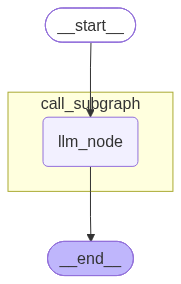

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
logger.remove()
logger.add(sys.stdout, colorize=True)

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 构建子图
def llm_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用子图的 llm_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile()  # Per-invocation（默认）：每次调用状态隔离
subgraph = builder.compile(checkpointer=True)   # Per-thread：历史相互干扰
# ==================================================

# 构建父图
class OverAllState(TypedDict):
    user_inputs: list[str] # 用户提问
    assistant_responses: str # 助手回答

def call_subgraph(state: OverAllState) -> OverAllState:
    user_inputs = state["user_inputs"]

    assistant_responses = []
    for user_input in user_inputs:
        subgraph_response = subgraph.invoke(
            {
                "messages": [
                    SystemMessage("用最简短的话回答用户的提问"),
                    HumanMessage(user_input)
                ]
            }
        )
        assistant_response = subgraph_response["messages"][-1].content
        assistant_responses.append(assistant_response)

    return {
        "assistant_responses": assistant_responses
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "multi-call-same-demo"}}

first_response = parent_graph.invoke(
    {
        "user_inputs": [
            "5*5等于几",
            "10*10等于几"
        ]
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "user_inputs": [
            "再+1呢?",
            "再+10000呢?"
        ]
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

## 调用不同子图
- 在一个节点里面调用多个子图，一旦子图调用顺序发生变化，历史检查点记录也会错乱

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.postgres import PostgresSaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
logger.remove()
logger.add(sys.stdout, colorize=True)

from common import init_simple_dashscope_model, load_postgresql_url

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# ==================================================
# 【策略切换点】两个子图的编译参数
# ==================================================

# 构建水果子图
def fruit_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用水果子图的 fruit_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("fruit_node", fruit_node)
builder.add_edge(START, "fruit_node")
builder.add_edge("fruit_node", END)

fruit_subgraph = builder.compile(checkpointer=True)

# 构建蔬菜子图
def vegetable_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用蔬菜子图的 vegetable_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("vegetable_node", vegetable_node)
builder.add_edge(START, "vegetable_node")
builder.add_edge("vegetable_node", END)

vegetable_subgraph = builder.compile(checkpointer=True)

# 构建父图
class OverAllState(TypedDict):
    fruit: str # 水果
    vegetable: str # 蔬菜

    fruit_introduction: str # 水果介绍
    vegetable_introduction: str # 蔬菜介绍

def call_subgraph(state: OverAllState) -> OverAllState:
    fruit = state["fruit"]
    vegetable = state["vegetable"]

    fruit_messages = [
        SystemMessage("用最简短的话介绍用户输入的水果"),
        HumanMessage(fruit)
    ]

    vegetable_messages = [
        SystemMessage("用最简短的话介绍用户输入的蔬菜"),
        HumanMessage(vegetable)
    ]
    fruit_response = fruit_subgraph.invoke({"messages": fruit_messages})
    vegetable_response = vegetable_subgraph.invoke({"messages": vegetable_messages})


    fruit_introduction = fruit_response["messages"][-1].content
    vegetable_introduction = vegetable_response["messages"][-1].content

    return {
        "fruit_introduction": fruit_introduction,
        "vegetable_introduction": vegetable_introduction
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)


with PostgresSaver.from_conn_string(load_postgresql_url()) as checkpointer:
    parent_graph = builder.compile(checkpointer=checkpointer)

    config = {"configurable": {"thread_id": "multi-call-diff-demo"}}

    first_response = parent_graph.invoke(
        {
            "fruit": "桑葚",
            "vegetable": "西兰苔"
        },
        config = config
    )
    print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
    print(first_response)

    second_response = parent_graph.invoke(
        {
            "fruit": "香蕉",
            "vegetable": "西兰花"
        },
        config = config
    )
    print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
    print(second_response)

    # from IPython.display import display, Image
    # display(
    #     Image(
    #         parent_graph
    #         .get_graph(xray=True)
    #         .draw_mermaid_png()
    #     )
    # )


    from rich import print as rprint
    parent_graph = list(parent_graph.get_state_history(config=config))

    rprint(parent_graph)

## 独立调用不同子图（多子图最佳方案）

2026-08-14 19:44:24.883 | INFO     | __main__:fruit_node:25 - ==============================
2026-08-14 19:44:24.886 | INFO     | __main__:fruit_node:26 - 调用水果子图的 fruit_node 节点，当前的 messages: 
2026-08-14 19:44:24.887 | INFO     | __main__:fruit_node:28 - 
[消息 1]
类型：system
内容：用最简短的话介绍用户输入的水果
2026-08-14 19:44:24.886 | INFO     | __main__:vegetable_node:54 - ==============================
2026-08-14 19:44:24.888 | INFO     | __main__:fruit_node:28 - 
[消息 2]
类型：human
内容：桑葚
2026-08-14 19:44:24.890 | INFO     | __main__:fruit_node:36 - ==============================
2026-08-14 19:44:24.890 | INFO     | __main__:vegetable_node:55 - 调用蔬菜子图的 vegetable_node 节点，当前的 messages: 
2026-08-14 19:44:24.895 | INFO     | __main__:vegetable_node:57 - 
[消息 1]
类型：system
内容：用最简短的话介绍用户输入的蔬菜
2026-08-14 19:44:24.896 | INFO     | __main__:vegetable_node:57 - 
[消息 2]
类型：human
内容：西兰苔
2026-08-14 19:44:24.898 | INFO     | __main__:vegetable_node:65 - ==============================
============================== -> 第一次

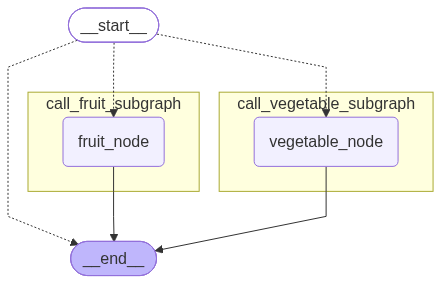

In [24]:
from typing import TypedDict, Literal
from collections.abc import Sequence
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain.messages import HumanMessage, SystemMessage, AIMessage
from langchain_deepseek import ChatDeepSeek

import sys
from loguru import logger
logger.remove()
logger.add(sys.stdout, colorize=True)

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 构建水果子图
def fruit_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用水果子图的 fruit_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("fruit_node", fruit_node)
builder.add_edge(START, "fruit_node")
builder.add_edge("fruit_node", END)

fruit_subgraph = builder.compile(checkpointer=True)

# 构建蔬菜子图
def vegetable_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    logger.info("=" * 30)
    logger.info("调用蔬菜子图的 vegetable_node 节点，当前的 messages: ")
    for index, message in enumerate(messages, start=1):
        logger.opt(colors=True).info(
            "\n<cyan><bold>[消息 {}]</bold></cyan>\n"
            "<yellow>类型：</yellow><magenta>{}</magenta>\n"
            "<yellow>内容：</yellow><green>{}</green>",
            index,
            message.type,
            message.content
        )
    logger.info("=" * 30)
    response = model.invoke(input=messages)
    ai_msg = AIMessage(content=response.content)

    return {
        "messages": [ai_msg]
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("vegetable_node", vegetable_node)
builder.add_edge(START, "vegetable_node")
builder.add_edge("vegetable_node", END)

vegetable_subgraph = builder.compile(checkpointer=True)

# 构建父图
class OverAllState(TypedDict):
    fruit: str # 水果
    vegetable: str # 蔬菜

    fruit_introduction: str # 水果介绍
    vegetable_introduction: str # 蔬菜介绍

def call_fruit_subgraph(state: OverAllState) -> OverAllState:
    fruit = state["fruit"]

    fruit_messages = [
        SystemMessage("用最简短的话介绍用户输入的水果"),
        HumanMessage(fruit)
    ]

    fruit_response = fruit_subgraph.invoke({"messages": fruit_messages})
    fruit_introduction = fruit_response["messages"][-1].content

    return {
        "fruit_introduction": fruit_introduction
    }

def call_vegetable_subgraph(state: OverAllState) -> OverAllState:
    vegetable = state["vegetable"]

    vegetable_messages = [
        SystemMessage("用最简短的话介绍用户输入的蔬菜"),
        HumanMessage(vegetable)
    ]

    vegetable_response = vegetable_subgraph.invoke({"messages": vegetable_messages})
    vegetable_introduction = vegetable_response["messages"][-1].content

    return {
        "vegetable_introduction": vegetable_introduction
    }

def router(state: OverAllState) -> Sequence[Literal["call_fruit_subgraph", "call_vegetable_subgraph", '__end__']]:
    next_nodes = []
    if state.get("fruit"):
        next_nodes.append("call_fruit_subgraph")
    if state.get("vegetable"):
        next_nodes.append("call_vegetable_subgraph")
    if not next_nodes:
        next_nodes.append(END)
    return next_nodes

builder = StateGraph(state_schema=OverAllState)
builder.add_node("call_fruit_subgraph", call_fruit_subgraph)
builder.add_node("call_vegetable_subgraph", call_vegetable_subgraph)

builder.add_conditional_edges(START, router, path_map=["call_fruit_subgraph", "call_vegetable_subgraph", END])
builder.add_edge("call_fruit_subgraph", END)
builder.add_edge("call_vegetable_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "independent-nodes-demo"}}

first_response = parent_graph.invoke(
    {
        "fruit": "桑葚",
        "vegetable": "西兰苔"
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "fruit": "香蕉",
        "vegetable": "西兰花"
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

## Stateless

============================== -> 第一次运行结果 <- ==============================
{'input_texts': ['  LangGraph 真有意思 ', '  我喜欢 LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain']}
============================== -> 第二次运行结果 <- ==============================
{'input_texts': ['  Hello, LangGraph  ', '  Hello, LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain', 'Hello, LangGraph', 'Hello, LangChain']}


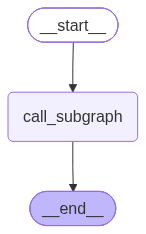

In [33]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str
    clean_texts: Annotated[list[str], add]

def strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    clean_text = raw_text.strip()

    return {
        "clean_texts": [clean_text]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("strip_node", strip_node)
builder.add_edge(START, "strip_node")
builder.add_edge("strip_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
subgraph = builder.compile(checkpointer=False)  # Stateless：无检查点
# subgraph = builder.compile(checkpointer=True)   # Per-thread：有状态（对比用）
# ==================================================

# 构建父图
class ParentState(TypedDict):
    input_texts: list[str]
    output_texts: Annotated[list[str], add]

def call_subgraph(state: ParentState) -> ParentState:
    input_texts = state["input_texts"]

    output_texts = []
    for input_text in input_texts:
        res = subgraph.invoke({"raw_text": input_text})
        output_texts += res["clean_texts"]

    return {
        "output_texts": output_texts
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "stateless-demo"}}

first_response = parent_graph.invoke(
    {
        "input_texts": ["  LangGraph 真有意思 ", "  我喜欢 LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "input_texts": ["  Hello, LangGraph  ", "  Hello, LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)